# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [1]:
# If on colab, uncomment the following lines

! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

--2025-11-16 17:59:59--  https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58374 (57K) [text/plain]
Saving to: ‘car_data.csv’

car_data.csv        100%[===================>]  57.01K  --.-KB/s    in 0.001s  

2025-11-16 17:59:59 (37.3 MB/s) - ‘car_data.csv’ saved [58374/58374]



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [3]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,316,91,41,66,131,56,9,126,53,18,144,159,237,155,72,3,10,191,194
1,483,86,38,76,143,59,8,142,47,18,131,167,301,138,71,5,10,189,196
2,492,85,43,66,130,57,6,151,45,19,143,173,333,168,86,4,9,180,183
3,543,96,37,74,187,68,8,159,42,20,134,183,378,134,69,3,16,190,197
4,539,109,55,96,191,57,6,241,28,26,170,267,857,242,85,8,9,184,184
5,732,85,45,73,167,69,8,143,46,18,148,173,307,176,71,2,0,190,199
6,1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199
7,353,81,47,69,146,64,6,151,44,19,147,171,340,195,75,5,0,183,188
8,836,87,45,66,139,58,8,140,47,18,148,168,294,175,73,3,12,188,196
9,591,80,36,69,127,56,7,128,53,18,124,147,240,133,70,2,21,183,191


Methods `describe` and `info` deliver some useful information.

In [ ]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,432.114754,93.839709,44.765027,81.872495,169.358834,61.817851,8.433515,168.934426,40.865209,20.588342,147.571949,188.744991,440.672131,174.539162,72.449909,6.557377,12.568306,189.030965,195.491803
std,240.666501,8.335779,6.190806,15.647408,32.834864,7.971412,4.491440,33.163102,7.790602,2.588917,14.451808,31.241299,176.701194,32.845869,7.308114,5.006099,9.010809,6.200788,7.435024
min,0.000000,77.000000,33.000000,40.000000,104.000000,47.000000,3.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,60.000000,0.000000,0.000000,177.000000,181.000000
25%,225.000000,87.000000,40.000000,70.000000,142.000000,57.000000,6.000000,147.000000,34.000000,19.000000,136.000000,167.000000,319.000000,149.000000,67.000000,2.000000,5.000000,184.000000,190.000000
50%,431.000000,93.000000,44.000000,79.000000,169.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,367.000000,174.000000,71.000000,6.000000,11.000000,189.000000,197.000000
75%,644.000000,100.000000,49.000000,96.000000,195.000000,65.000000,10.000000,195.000000,46.000000,22.000000,159.000000,216.000000,575.000000,198.000000,75.000000,10.000000,19.000000,193.000000,201.000000
max,845.000000,119.000000,59.000000,112.000000,322.000000,133.000000,52.000000,265.000000,61.000000,29.000000,186.000000,287.000000,1018.000000,268.000000,127.000000,22.000000,41.000000,206.000000,211.000000


In [ ]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [4]:
### YOUR CODE HERE

from sklearn.preprocessing import StandardScaler

# стандартизация признаков, как обычно вычитаем среднее и делим на стандартное отклонение
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# что там получилось
print("Стандартизированные данные:")
print(X_train_scaled[:5])

# это нужно сделать, потому что признаки имеют разный масштаб (например, одни признаки в диапазоне [0, 100], другие — [0, 1000]).
# это может негативно влиять на работу алгоритмов, чувствительных к масштабу (SVM, kNN, градиентный спуск).


Стандартизированные данные:
[[-0.45281762 -0.28947236 -0.61019792 -0.98600944 -1.11268254 -0.70099787
   0.11712475 -1.26501054  1.52010362 -0.9723765  -0.25500568 -0.92177196
  -1.12299009 -0.59488291 -0.08823646 -0.67506191 -0.28887667  0.36753874
  -0.17575983]
 [ 0.24314694 -0.89929708 -1.10722858 -0.34961256 -0.74152545 -0.31239353
  -0.09937857 -0.7790553   0.74595066 -0.9723765  -1.17558005 -0.66326852
  -0.75731555 -1.12699352 -0.2235488  -0.26395932 -0.28887667  0.04156335
   0.08969312]
 [ 0.28065401 -1.02126203 -0.27884416 -0.98600944 -1.1436123  -0.57146309
  -0.53238521 -0.50570547  0.48789968 -0.58214646 -0.32581909 -0.46939093
  -0.57447828 -0.18797479  1.8061363  -0.46951061 -0.40001423 -1.42532592
  -1.63575109]
 [ 0.49319409  0.32035237 -1.27290546 -0.47689194  0.61938389  0.85341949
  -0.09937857 -0.26272785  0.1008232  -0.19191641 -0.96313981 -0.14626163
  -0.31736337 -1.25219602 -0.49417348 -0.67506191  0.37794867  0.20455104
   0.2224196 ]
 [ 0.47652428  1.9058966

In [5]:
np.unique(y_train, return_counts=True)

(array(['bus', 'opel', 'saab', 'van'], dtype=object),
 array([148, 134, 134, 133]))

<font color=brown size=+1>классы вроде бы сбалансированы </font>

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [11]:
# You might use this command to install scikit-plot.
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding
# virtual environment instead

# ! pip install scikit-plot
! pip install git+https://github.com/scikit-plots/scikit-plots.git

  Cloning https://github.com/scikit-plots/scikit-plots.git to /tmp/pip-req-build-90gnrhvi
  Running command git clone --filter=blob:none --quiet https://github.com/scikit-plots/scikit-plots.git /tmp/pip-req-build-90gnrhvi
  Resolved https://github.com/scikit-plots/scikit-plots.git to commit 1976a98cb395319f7db1a57ded117e25c344632f
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.6 MB/s eta 0:00:00
  Created wheel for scikit-plots: filename=scikit_plots-0.4.0.post6-cp312-cp312-linux_x86_64.whl size=4204722 sha256=a28b6826edd0313edeb85d85021e960764ff2cc51e87c17c9e5a179ebd685d9e
  Stored in directory: /tmp/pip-ephem-wheel-cache-gsm2eys_/wheels/ea/67/28/822a91bad10bf550e7920c47053d8ff74ba8d1cc79a2787ad0
Successfully built scikit-plots


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Лучшие параметры: {'C': 10, 'penalty': 'l1'}
Лучший F1-score (CV): 0.8106844469744597

Accuracy на тесте: 0.7609
F1-score (macro) на тесте: 0.7758


<Figure size 800x600 with 0 Axes>

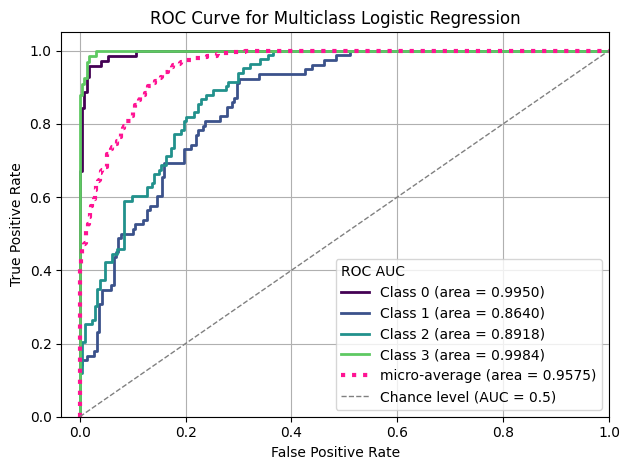

In [12]:
### YOUR CODE HERE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import scikitplot as skplt
import matplotlib.pyplot as plt
import numpy as np

# параметры модели заданы в условии
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    tol=1e-3,
    max_iter=500,
    random_state=42
)

# поиск по сетке гиперпараметров
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# обучение, там и поиск внутри
grid_search.fit(X_train_scaled, y_train)

# что там нашлось
best_log_reg = grid_search.best_estimator_
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший F1-score (CV):", grid_search.best_score_)

# предсказания на тесте
y_pred = best_log_reg.predict(X_test_scaled)
y_pred_proba = best_log_reg.predict_proba(X_test_scaled)

# нас просили эти метрики
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nAccuracy на тесте: {accuracy:.4f}")
print(f"F1-score (macro) на тесте: {f1:.4f}")

# ROC-кривая
plt.figure(figsize=(8, 6))
skplt.metrics.plot_roc(y_test, y_pred_proba, title="ROC Curve for Multiclass Logistic Regression")
plt.show()

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot.

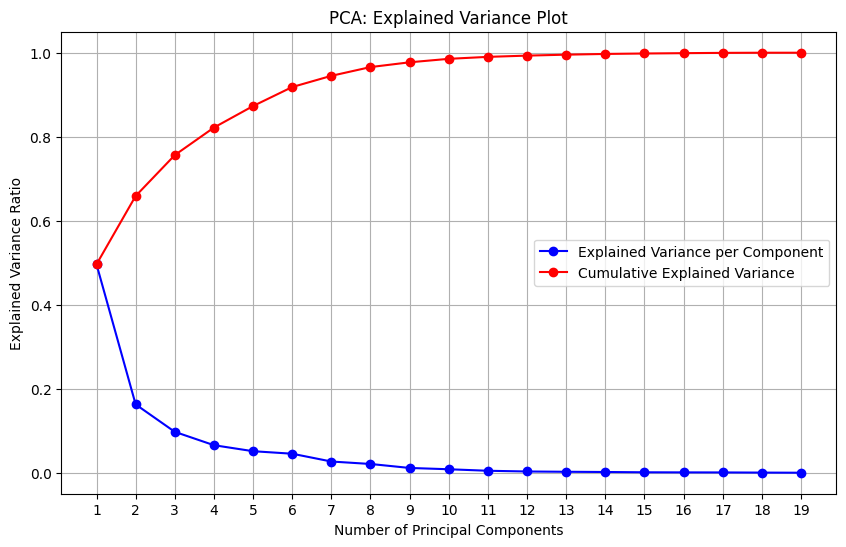

Для объяснения 95% дисперсии достаточно 8 компонент.


In [13]:
### YOUR CODE HERE

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# данные стандартизиованы к [-1,1] со средним 0 PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# explained дисперсия
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(explained_variance_ratio) + 1),
         explained_variance_ratio, 'bo-', label='Explained Variance per Component')
plt.plot(range(1, len(cumulative_variance_ratio) + 1),
         cumulative_variance_ratio, 'ro-', label='Cumulative Explained Variance')

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Explained Variance Plot')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

# сколько компонент нужно для 95% дисперсии
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"Для объяснения 95% дисперсии достаточно {n_components_95} компонент.")

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

In [14]:
### YOUR CODE HERE

# PCA с выбранным числом компонент
pca = PCA(n_components=n_components_95)

pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Проверим формы
print("Форма X_train_pca:", X_train_pca.shape)
print("Форма X_test_pca:", X_test_pca.shape)

Форма X_train_pca: (549, 8)
Форма X_test_pca: (297, 8)


**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Accuracy на тесте: 0.6094
F1-score (macro) на тесте: 0.6058
Лучшие параметры: {'log_reg__C': 10, 'log_reg__penalty': 'l2'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

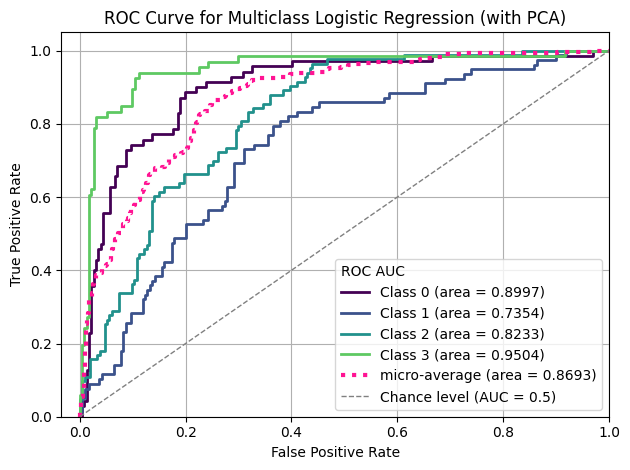

In [15]:
### YOUR CODE HERE

# scikitplot установлен там выше, из гитлаба, другой не работает

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import scikitplot as skplt
import matplotlib.pyplot as plt
import numpy as np

# PCA внутри одного пайплайна
# чтобы объединить стандартизацию, PCA и логистическую регрессию
# в один конвейер.
# Это чтобы PCA обучался только на тренировочных данных
# при каждой итерации кросс-валидации, что предотвращает утечку данных
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # 95% дисперсии
    ('log_reg', LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        tol=1e-3,
        max_iter=500,
        random_state=42
    ))
])

# гиперпараметры
param_grid = {
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2']
}

# Поиск по сетке
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# подберем их
grid_search.fit(X_train, y_train)
# grid_search.fit(X_train_pca, y_train)

# лучшая модель
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nAccuracy на тесте: {accuracy:.4f}")
print(f"F1-score (macro) на тесте: {f1:.4f}")
print("Лучшие параметры:", grid_search.best_params_)

# ROC-кривая
plt.figure(figsize=(8, 6))
skplt.metrics.plot_roc(y_test, y_pred_proba, title="ROC Curve for Multiclass Logistic Regression (with PCA)")
plt.show()

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [17]:
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# grid_search_dt.fit(X_train_pca, y_train)
grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
print("Лучшие параметры:", grid_search_dt.best_params_)
print("Лучший F1-score (CV):", grid_search_dt.best_score_)

#y_pred_dt = best_dt.predict(X_test_pca)
#y_pred_proba_dt = best_dt.predict_proba(X_test_pca)
y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='macro')

print(f"\nAccuracy на тесте: {accuracy_dt:.4f}")
print(f"F1-score (macro) на тесте: {f1_dt:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Лучшие параметры: {'max_depth': 15}
Лучший F1-score (CV): 0.7007920282511686

Accuracy на тесте: 0.6970
F1-score (macro) на тесте: 0.7150


#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

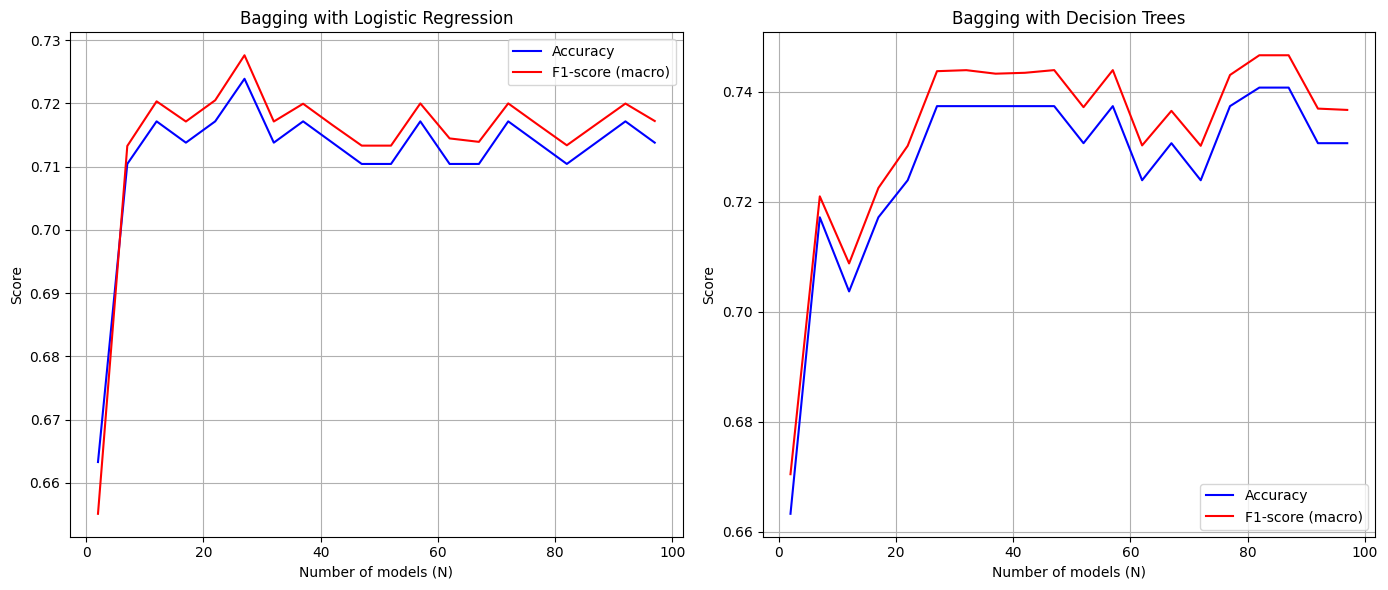


Что в итоге получилось:
1. Оптимальное число алгоритмов — около 50–70, потому что после этого метрики перестают значительно расти.
2. Гиперпараметры деревьев из 2.5 подходят для ансамбля, так как бэггинг сам снижает дисперсию — даже если одно дерево немного переобучено, ансамбль будет работать хорошо.


In [18]:
# YOUR CODE HERE

from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

N_min = 2
N_max = 100
step = 5
n_values = list(range(N_min, N_max + 1, step))

# Ансамбль логистических регрессий
# лучшие параметры из 2.1: {'C': 10, 'penalty': 'l1'}
log_reg_params = {
    'multi_class': 'multinomial',
    'solver': 'saga',
    'tol': 1e-3,
    'max_iter': 500,
    'random_state': 42,
    'C': 10,
    'penalty': 'l1'
}

base_log_reg = LogisticRegression(**log_reg_params)
accuracy_bag_log = []
f1_bag_log = []

for n in n_values:
    bag_log = BaggingClassifier(
        estimator=base_log_reg,
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    bag_log.fit(X_train, y_train)
    y_pred = bag_log.predict(X_test)
    accuracy_bag_log.append(accuracy_score(y_test, y_pred))
    f1_bag_log.append(f1_score(y_test, y_pred, average='macro'))

# Ансамбль деревьев решений
# лучшие параметры из 2.5: {'max_depth': 15}
dt_params = {
    'max_depth': 15,
    'random_state': 42
}

base_dt = DecisionTreeClassifier(**dt_params)
accuracy_bag_dt = []
f1_bag_dt = []

for n in n_values:
    bag_dt = BaggingClassifier(
        estimator=base_dt,
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    bag_dt.fit(X_train, y_train)
    y_pred = bag_dt.predict(X_test)
    accuracy_bag_dt.append(accuracy_score(y_test, y_pred))
    f1_bag_dt.append(f1_score(y_test, y_pred, average='macro'))


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(n_values, accuracy_bag_log, 'b-', label='Accuracy')
plt.plot(n_values, f1_bag_log, 'r-', label='F1-score (macro)')
plt.xlabel('Number of models (N)')
plt.ylabel('Score')
plt.title('Bagging with Logistic Regression')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_values, accuracy_bag_dt, 'b-', label='Accuracy')
plt.plot(n_values, f1_bag_dt, 'r-', label='F1-score (macro)')
plt.xlabel('Number of models (N)')
plt.ylabel('Score')
plt.title('Bagging with Decision Trees')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Анализ

print("\nЧто в итоге получилось:")
print("1. Оптимальное число алгоритмов — около 50–70, потому что после этого метрики перестают значительно расти.")
print("2. Гиперпараметры деревьев из 2.5 подходят для ансамбля, так как бэггинг сам снижает дисперсию — даже если одно дерево немного переобучено, ансамбль будет работать хорошо.")

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

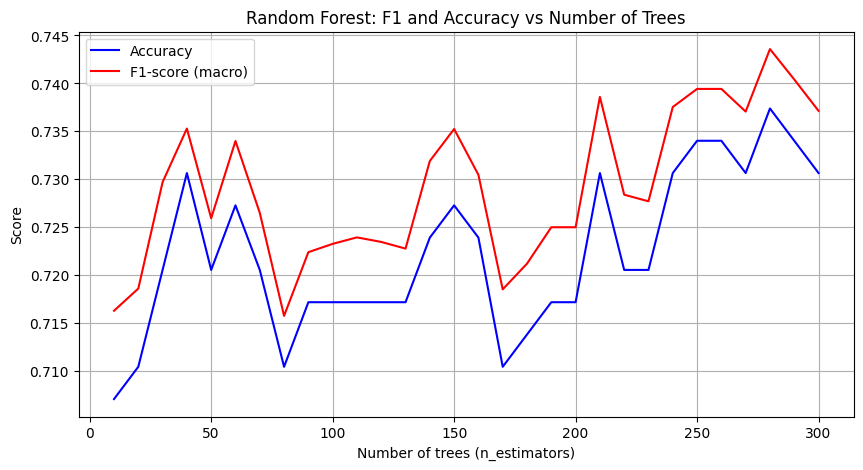


Анализ:
1. Оптимальное число деревьев - 250-275, потому что после этого метрики перестают значительно расти.
2. Это отличается от Bagging (2.6), где оптимальное число было 50–70. Причина: Random Forest использует случайный выбор признаков, что снижает корреляцию между деревьями и позволяет строить большие ансамбли без переобучения.
3. Random Forest обычно показывает лучшее качество, чем Bagging, благодаря дополнительному регуляризирующему эффекту случайного выбора признаков.


In [24]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE
# диапазон числа деревьев
n_estimators_range = list(range(10, 301, 10))  # от 10 до 200 с шагом 10

# где соберем хранения метрики
accuracy_rf = []
f1_rf = []

# глубину из 2.5
rf_params = {
    'random_state': 42,
    'n_jobs': -1,
    'max_depth': 15
}

# сбор метрик
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, **rf_params)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy_rf.append(accuracy_score(y_test, y_pred))
    f1_rf.append(f1_score(y_test, y_pred, average='macro'))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, accuracy_rf, 'b-', label='Accuracy')
plt.plot(n_estimators_range, f1_rf, 'r-', label='F1-score (macro)')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Score')
plt.title('Random Forest: F1 and Accuracy vs Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

# Анализ
print("\nАнализ:")
print("1. Оптимальное число деревьев - 250-275, потому что после этого метрики перестают значительно расти.")
print("2. Это отличается от Bagging (2.6), где оптимальное число было 50–70. Причина: Random Forest использует случайный выбор признаков, что снижает корреляцию между деревьями и позволяет строить большие ансамбли без переобучения.")
print("3. Random Forest обычно показывает лучшее качество, чем Bagging, благодаря дополнительному регуляризирующему эффекту случайного выбора признаков.")

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it?

Обучение на 54 объектах...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Обучение на 108 объектах...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Обучение на 162 объектах...


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Обучение на 486 объектах...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Обучение на 540 объектах...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


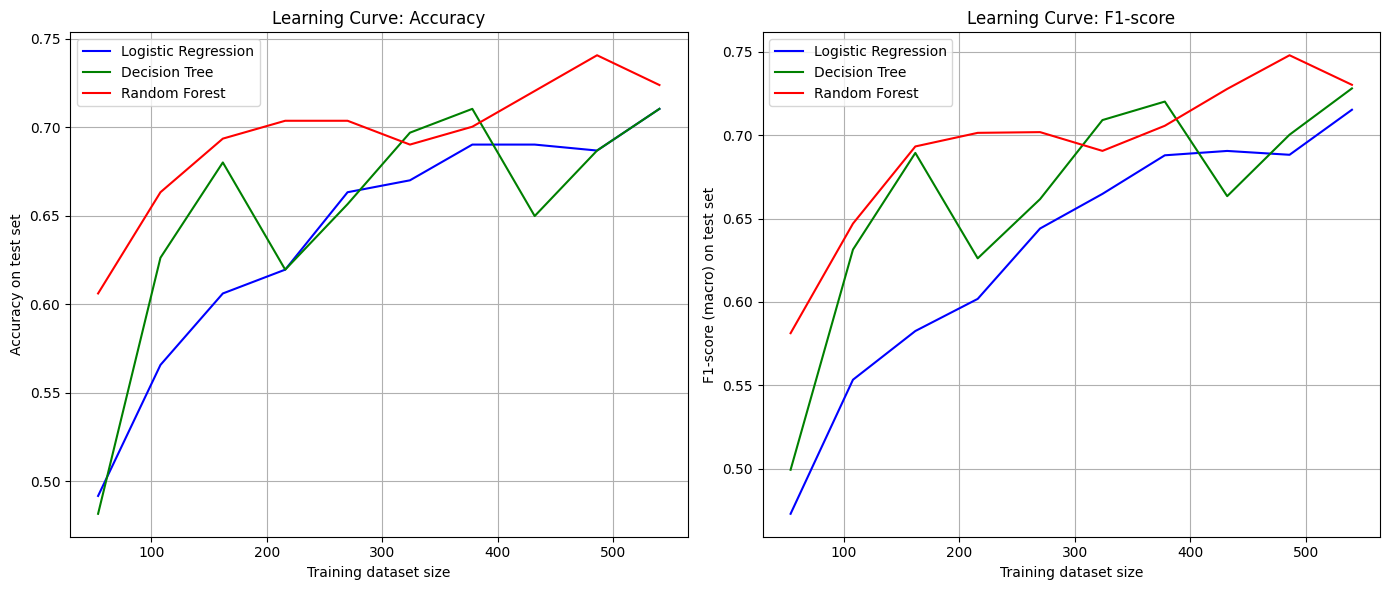


Анализ:
1. Random Forest демонстрирует наилучшее качество на всех размерах обучающей
   выборки — его accuracy и F1-score постоянно выше, чем у логистической
   регрессии и дерева решений. Это подтверждает его устойчивость и способность
   к обобщению.
2. Дерево решений показывает наибольшую нестабильность — резкие пики и провалы
   на графиках указывают на высокую дисперсию. Это означает, что модель сильно
   зависит от конкретного набора данных и склонна к переобучению, особенно при
   малом объёме данных.
3. Логистическая регрессия ведёт себя стабильно и плавно, но её качество
   остаётся ниже, чем у Random Forest. Это типично для линейных моделей — они
   менее чувствительны к шуму, но не могут уловить сложные нелинейные
   зависимости.
4. Все модели показывают рост качества с увеличением размера обучающих данных,
   что говорит об отсутствии недообучения. Однако после ~500 объектов рост
   метрик замедляется — это значит, что дальнейшее увеличение данных не
   принесёт значительн

In [26]:
# YOUR CODE HERE

# количество частей
n_parts = 10
part_size = len(X_train) // n_parts

train_sizes = []
accuracy_log = []
f1_log = []
accuracy_dt = []
f1_dt = []
accuracy_rf = []
f1_rf = []

# оптимальные параметры (замените на ваши!)
log_reg_params = {
    'multi_class': 'multinomial',
    'solver': 'saga',
    'tol': 1e-3,
    'max_iter': 500,
    'random_state': 42,
    'C': 10,
    'penalty': 'l1'
}

dt_params = {
    'max_depth': 15,
    'random_state': 42
}

# из 2.7
rf_params = {
    'max_depth': 15,
    'n_estimators': 250,
    'random_state': 42,
    'n_jobs': -1
}

for i in range(1, n_parts + 1):
    end_idx = i * part_size
    X_train_part = X_train[:end_idx]
    y_train_part = y_train[:end_idx]

    train_sizes.append(len(X_train_part))
    print(f"Обучение на {len(X_train_part)} объектах...")

    # Логистическая регрессия
    log_reg = LogisticRegression(**log_reg_params)
    log_reg.fit(X_train_part, y_train_part)
    y_pred_log = log_reg.predict(X_test)
    accuracy_log.append(accuracy_score(y_test, y_pred_log))
    f1_log.append(f1_score(y_test, y_pred_log, average='macro'))

    # Дерево решений
    dt = DecisionTreeClassifier(**dt_params)
    dt.fit(X_train_part, y_train_part)
    y_pred_dt = dt.predict(X_test)
    accuracy_dt.append(accuracy_score(y_test, y_pred_dt))
    f1_dt.append(f1_score(y_test, y_pred_dt, average='macro'))

    # Random Forest
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train_part, y_train_part)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf.append(accuracy_score(y_test, y_pred_rf))
    f1_rf.append(f1_score(y_test, y_pred_rf, average='macro'))


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, accuracy_log, 'b-', label='Logistic Regression')
plt.plot(train_sizes, accuracy_dt, 'g-', label='Decision Tree')
plt.plot(train_sizes, accuracy_rf, 'r-', label='Random Forest')
plt.xlabel('Training dataset size')
plt.ylabel('Accuracy on test set')
plt.title('Learning Curve: Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_sizes, f1_log, 'b-', label='Logistic Regression')
plt.plot(train_sizes, f1_dt, 'g-', label='Decision Tree')
plt.plot(train_sizes, f1_rf, 'r-', label='Random Forest')
plt.xlabel('Training dataset size')
plt.ylabel('F1-score (macro) on test set')
plt.title('Learning Curve: F1-score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nАнализ:\n"
      "1. Random Forest демонстрирует наилучшее качество на всех размерах обучающей\n"
      "   выборки — его accuracy и F1-score постоянно выше, чем у логистической\n"
      "   регрессии и дерева решений. Это подтверждает его устойчивость и способность\n"
      "   к обобщению.\n"
      "2. Дерево решений показывает наибольшую нестабильность — резкие пики и провалы\n"
      "   на графиках указывают на высокую дисперсию. Это означает, что модель сильно\n"
      "   зависит от конкретного набора данных и склонна к переобучению, особенно при\n"
      "   малом объёме данных.\n"
      "3. Логистическая регрессия ведёт себя стабильно и плавно, но её качество\n"
      "   остаётся ниже, чем у Random Forest. Это типично для линейных моделей — они\n"
      "   менее чувствительны к шуму, но не могут уловить сложные нелинейные\n"
      "   зависимости.\n"
      "4. Все модели показывают рост качества с увеличением размера обучающих данных,\n"
      "   что говорит об отсутствии недообучения. Однако после ~500 объектов рост\n"
      "   метрик замедляется — это значит, что дальнейшее увеличение данных не\n"
      "   принесёт значительного улучшения.\n"
      "5. Разница между моделями особенно заметна на малых данных (<200 объектов) —\n"
      "   здесь Random Forest и логистическая регрессия значительно превосходят дерево.\n"
      "   Это говорит о том, что ансамблевые методы (включая RF) лучше работают при\n"
      "   ограниченном количестве данных."
)